Q5 — Standardiser les fichiers audio
Le problème : les fichiers ont des sample rates différents (16 000, 22 050, 44 100 Hz) et des durées variables. Un CNN attend des tenseurs de taille strictement identique en entrée — il faut tout normaliser.

In [1]:
import librosa
import numpy as np
import os

TARGET_SR      = 22050   # sample rate cible
TARGET_DURATION = 6.0    # secondes
TARGET_LEN     = int(TARGET_SR * TARGET_DURATION)  # = 132 300 samples

def load_and_standardize(filepath):
    # Chargement + resampling automatique vers 22050 Hz
    y, sr = librosa.load(filepath, sr=TARGET_SR, mono=True)

    # Trop long → on tronque
    if len(y) > TARGET_LEN:
        y = y[:TARGET_LEN]

    # Trop court → on padde avec des zéros (silence)
    elif len(y) < TARGET_LEN:
        y = np.pad(y, (0, TARGET_LEN - len(y)), mode='constant')

    # Normalisation amplitude entre -1 et 1
    max_val = np.abs(y).max()
    if max_val > 0:
        y = y / max_val

    return y  # shape garantie : (132300,)

Pourquoi 22 050 Hz ? C'est le standard audio "basse def" — suffisant pour capturer tous les sons respiratoires (qui sont sous 4 000 Hz) sans surcharger la mémoire. Pourquoi 6 secondes ? C'est la durée médiane d'un cycle respiratoire complet dans ce dataset.

Q6 — Mel-spectrogrammesLe Mel-spectrogramme est ce qu'on va donner à manger au CNN — c'est une image 2D qui représente l'énergie sonore dans le temps (axe X) et en fréquence (axe Y, échelle Mel qui imite la perception humaine).

In [2]:
import librosa
import numpy as np

def compute_mel_spectrogram(y, sr=22050):
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128,      # nombre de bandes de fréquences → hauteur de l'image
        n_fft=2048,      # taille de la fenêtre FFT → résolution fréquentielle
        hop_length=512,  # pas entre chaque fenêtre → résolution temporelle
        # fmax=4000        # fréquence max utile pour sons respiratoires
    )

    # Conversion en décibels (échelle logarithmique, plus lisible)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Normalisation entre 0 et 1 pour le CNN
    mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min())

    return mel_norm  # shape : (128, 259) → image 128×259 pixels

Les paramètres expliqués simplement : n_fft=2048 détermine la précision en fréquence (plus grand = plus précis mais plus lent), hop_length=512 détermine la précision temporelle (plus petit = plus de colonnes dans l'image), et n_mels=128 c'est la résolution verticale de l'image finale.


Q7 — Features acoustiques complémentaires
En plus du Mel-spectrogramme pour le CNN, on extrait des features numériques pour des modèles plus simples (Random Forest, XGBoost) ou pour enrichir le CNN.

In [3]:
def extract_all_features(y, sr=22050):
    features = {}

    # MFCC — 13 coefficients qui résument l'enveloppe spectrale
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(13):
        features[f'mfcc_{i}_mean'] = float(mfcc[i].mean())
        features[f'mfcc_{i}_std']  = float(mfcc[i].std())

    # Spectral Centroid — "centre de gravité" fréquentiel
    # élevé = sons aigus (sifflements asthme), bas = sons graves (ronchi BPCO)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features['centroid_mean'] = float(centroid.mean())
    features['centroid_std']  = float(centroid.std())

    # Spectral Bandwidth — largeur du spectre autour du centroid
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features['bandwidth_mean'] = float(bandwidth.mean())

    # Zero Crossing Rate — nb de fois que le signal change de signe
    # élevé = sons bruités (crépitements pneumonie)
    zcr = librosa.feature.zero_crossing_rate(y)
    features['zcr_mean'] = float(zcr.mean())
    features['zcr_std']  = float(zcr.std())

    # Chroma — énergie par note musicale (12 notes)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features['chroma_mean'] = float(chroma.mean())

    # RMS Energy — énergie moyenne du signal
    rms = librosa.feature.rms(y=y)
    features['rms_mean'] = float(rms.mean())
    features['rms_std']  = float(rms.std())

    return features  # dict de ~32 valeurs numériques

Q8 — Filtrage du bruit
On applique un filtre passe-bande pour isoler uniquement les fréquences utiles (100–2000 Hz) et éliminer les bruits parasites comme les manipulations du stéthoscope ou la voix du soignant.

In [4]:
from scipy import signal as scipy_signal

def apply_bandpass_filter(y, sr=22050, lowcut=100, highcut=2000):
    # Filtre Butterworth ordre 4 — bon compromis précision/stabilité
    nyquist = sr / 2
    low  = lowcut  / nyquist
    high = highcut / nyquist

    b, a = scipy_signal.butter(N=4, Wn=[low, high], btype='band')
    y_filtered = scipy_signal.filtfilt(b, a, y)  # filtfilt = sans déphasage OU .trim

    return y_filtered

In [5]:
def compute_mfcc_spectrogram(y, sr=22050, n_mfcc=20):
    """MFCC - Mel-Frequency Cepstral Coefficients (20 coeffs)"""
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    
    # Conversion en décibels
    mfcc_db = librosa.power_to_db(mfcc, ref=np.max)
    
    # Normalisation entre 0 et 1
    mfcc_norm = (mfcc_db - mfcc_db.min()) / (mfcc_db.max() - mfcc_db.min() + 1e-8)
    
    return mfcc_norm  # shape : (13, temps)


def compute_spectral_centroid_spectrogram(y, sr=22050):
    """Spectral Centroid - centre de gravité fréquentiel"""
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    
    # Normalisation entre 0 et 1
    centroid_norm = (centroid - centroid.min()) / (centroid.max() - centroid.min() + 1e-8)
    
    return centroid_norm  # shape : (1, temps)


def compute_spectral_bandwidth_spectrogram(y, sr=22050):
    """Spectral Bandwidth - largeur du spectre"""
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    
    # Normalisation entre 0 et 1
    bandwidth_norm = (bandwidth - bandwidth.min()) / (bandwidth.max() - bandwidth.min() + 1e-8)
    
    return bandwidth_norm  # shape : (1, temps)


def compute_zcr_spectrogram(y, sr=22050):
    """Zero-Crossing Rate - nb de changement de signe"""
    zcr = librosa.feature.zero_crossing_rate(y)
    
    # Normalisation entre 0 et 1
    zcr_norm = (zcr - zcr.min()) / (zcr.max() - zcr.min() + 1e-8)
    
    return zcr_norm  # shape : (1, temps)


def compute_chroma_spectrogram(y, sr=22050):
    """Chroma - énergie par note musicale (12 notes)"""
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    
    # Normalisation entre 0 et 1
    chroma_norm = (chroma - chroma.min()) / (chroma.max() - chroma.min() + 1e-8)
    
    return chroma_norm  # shape : (12, temps)


In [6]:
import os
import numpy as np

DATASET_ROOT = "data_updated"
OUTPUT_FEATURES_NPY = "features_dataset.npy"
OUTPUT_SPECTRES_NPY = "spectres.npy"

all_features = []
all_mels = []
all_mfccs = []
all_centroids = []
all_bandwidths = []
all_zcrs = []
all_chromas = []
all_labels = []

for label in os.listdir(DATASET_ROOT):
    folder = os.path.join(DATASET_ROOT, label)
    if not os.path.isdir(folder):
        continue

    for wav_file in os.listdir(folder):
        if not wav_file.endswith(".wav"):
            continue

        filepath = os.path.join(folder, wav_file)

        try:
            # Étape 1 : chargement + standardisation
            y = load_and_standardize(filepath)

            # Étape 2 : filtrage bruit
            y_clean = apply_bandpass_filter(y, sr=TARGET_SR)

            # Étape 3 : Mel-spectrogramme
            mel = compute_mel_spectrogram(y_clean)
            all_mels.append(mel)

            # Étape 4 : MFCC
            mfcc = compute_mfcc_spectrogram(y_clean)
            all_mfccs.append(mfcc)

            # Étape 5 : Spectral Centroid
            centroid = compute_spectral_centroid_spectrogram(y_clean)
            all_centroids.append(centroid)

            # Étape 6 : Spectral Bandwidth
            bandwidth = compute_spectral_bandwidth_spectrogram(y_clean)
            all_bandwidths.append(bandwidth)

            # Étape 7 : Zero-Crossing Rate
            zcr = compute_zcr_spectrogram(y_clean)
            all_zcrs.append(zcr)

            # Étape 8 : Chroma
            chroma = compute_chroma_spectrogram(y_clean)
            all_chromas.append(chroma)

            # Étape 9 : features numériques complémentaires
            feats = extract_all_features(y_clean)
            feats['label'] = label
            feats['filename'] = wav_file
            all_features.append(feats)

            all_labels.append(label)

        except Exception as e:
            print(f"Erreur sur {wav_file} : {e}")

# Sauvegarde des features tabulaires en .npy (tableau d'objets)
features_array = np.array(all_features, dtype=object)
np.save(OUTPUT_FEATURES_NPY, features_array, allow_pickle=True)
print(f"Features sauvegardées : {OUTPUT_FEATURES_NPY} — {features_array.shape}")

# Sauvegarde de tous les spectres dans spectres.npy (dict)
spectres_dict = {
    "mel": np.array(all_mels),
    "mfcc": np.array(all_mfccs),
    "centroid": np.array(all_centroids),
    "bandwidth": np.array(all_bandwidths),
    "zcr": np.array(all_zcrs),
    "chroma": np.array(all_chromas),
    "labels": np.array(all_labels)
}
np.save(OUTPUT_SPECTRES_NPY, spectres_dict, allow_pickle=True)

print(f"Spectres sauvegardés : {OUTPUT_SPECTRES_NPY}")
print(f"  - Mel : {spectres_dict['mel'].shape}")
print(f"  - MFCC : {spectres_dict['mfcc'].shape}")
print(f"  - Centroid : {spectres_dict['centroid'].shape}")
print(f"  - Bandwidth : {spectres_dict['bandwidth'].shape}")
print(f"  - ZCR : {spectres_dict['zcr'].shape}")
print(f"  - Chroma : {spectres_dict['chroma'].shape}")

c:\Users\Paul\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Features sauvegardées : features_dataset.npy — (1211,)
Spectres sauvegardés : spectres.npy
  - Mel : (1211, 128, 259)
  - MFCC : (1211, 20, 259)
  - Centroid : (1211, 1, 259)
  - Bandwidth : (1211, 1, 259)
  - ZCR : (1211, 1, 259)
  - Chroma : (1211, 12, 259)


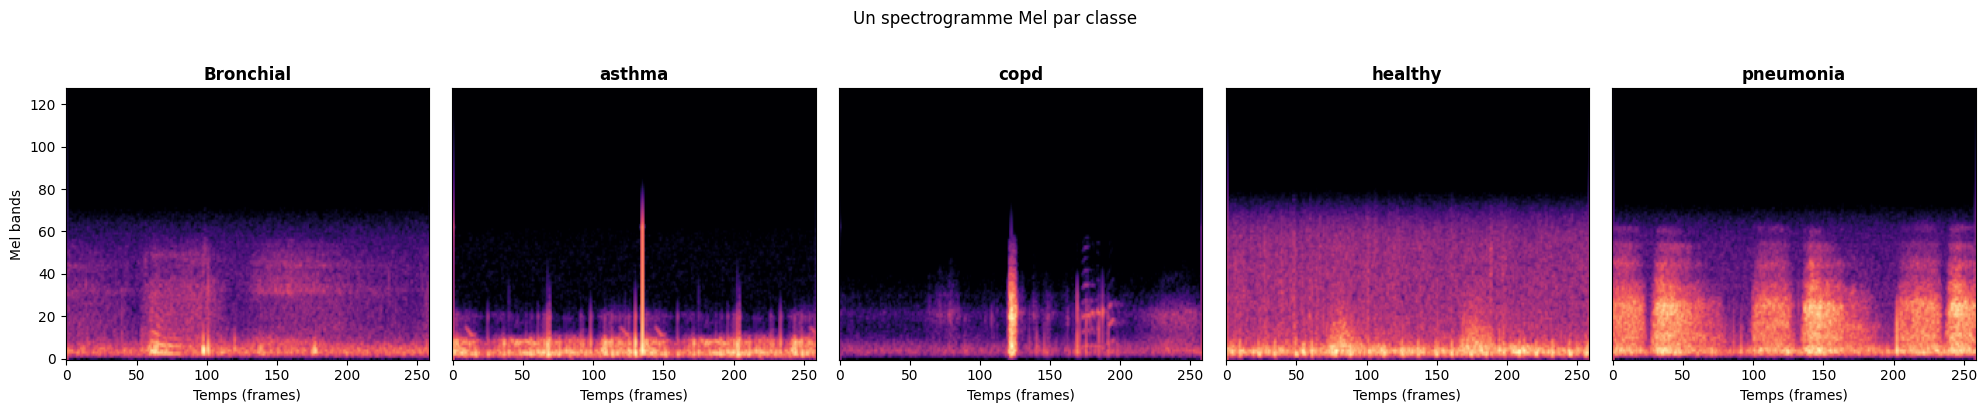

In [7]:
import matplotlib.pyplot as plt
spectres = np.load("spectres.npy", allow_pickle=True).item()
features = np.load("features_dataset.npy", allow_pickle=True)

mels = spectres["mel"]
assert len(mels) == len(features), "Désalignement entre spectres.npy et features_dataset.npy !"

labels = [row["label"] for row in features]
classes = np.unique(labels)

fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 4))
if len(classes) == 1:
    axes = [axes]

for ax, classe in zip(axes, classes):
    idx = labels.index(classe)

    ax.imshow(mels[idx], aspect='auto', origin='lower', cmap='magma')
    ax.set_title(classe, fontweight='bold')
    ax.set_xlabel("Temps (frames)")
    if ax == axes[0]:
        ax.set_ylabel("Mel bands")
    else:
        ax.set_yticks([])

plt.suptitle("Un spectrogramme Mel par classe", y=1.02)
plt.tight_layout()
plt.show()

Paramètres clés pour les spectrogrammes Mel (audio respiratoire)
### 🔹 `n_mels = 128`
- Correspond à la **hauteur de l’image** (nombre de bandes de fréquence).
- 128 bandes offrent une résolution suffisante pour distinguer :
  - **Sifflements aigus** (asthme, > 1000 Hz)
  - **Ronchi graves** (BPCO, < 500 Hz)
- En dessous de 64 :
  - perte de détails fréquentiels
  - difficulté à différencier certaines pathologies

---
### 🔹 `n_fft = 2048`
- Taille de la fenêtre utilisée pour la transformée de Fourier (FFT).
- Représente un **compromis temps / fréquence** :
  - grande fenêtre → meilleure précision fréquentielle
  - mais moins bonne résolution temporelle (effet de “flou”)
- À 22 050 Hz :
  - 2048 échantillons ≈ **93 ms**
- Suffisant pour :
  - capturer une partie d’un cycle respiratoire
  - conserver une localisation temporelle correcte

---

### 🔹 `hop_length = 512`
- Détermine le **pas entre deux fenêtres FFT** → donc la **largeur de l’image**
- Exemple :
  - 6 secondes × 22 050 Hz = 132 300 échantillons
  - 132 300 / 512 ≈ **259 colonnes (frames temporelles)** 

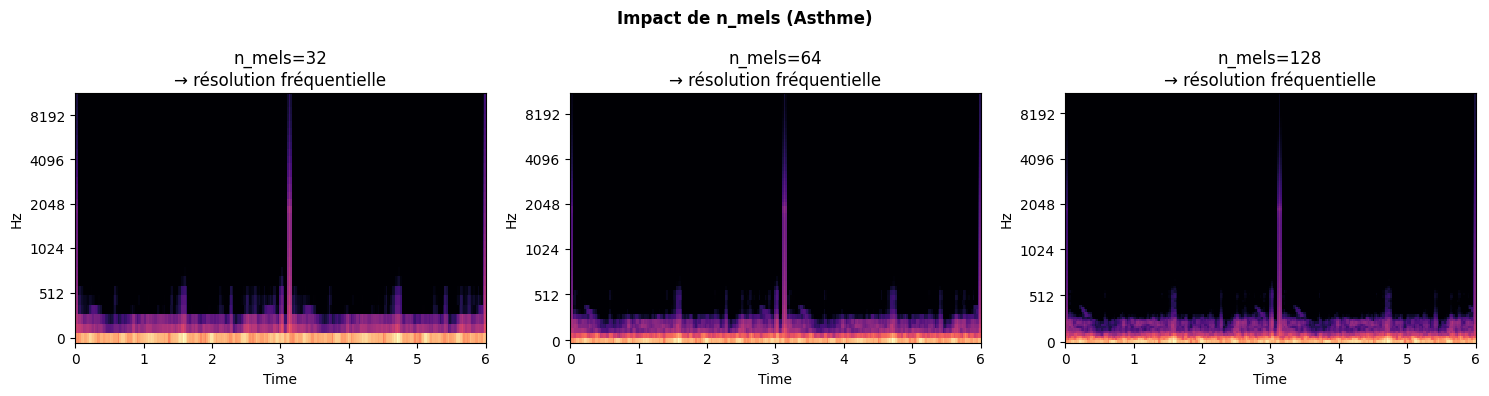

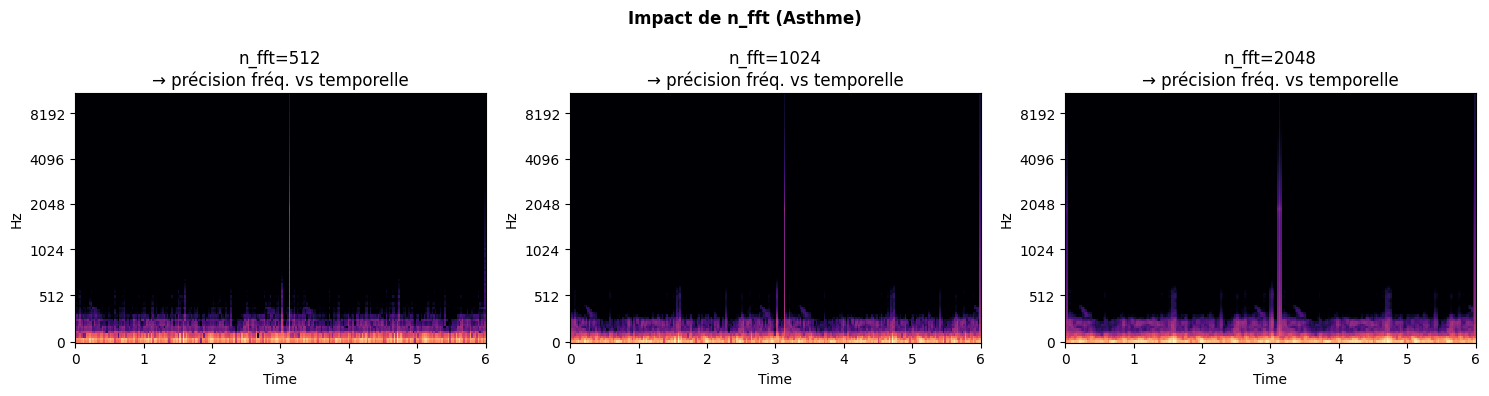

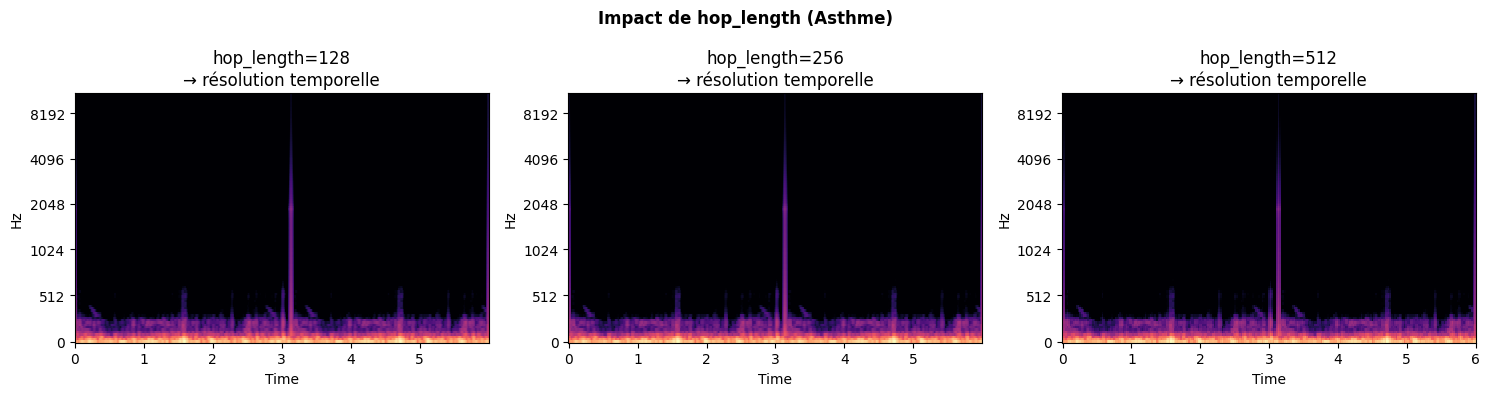

In [8]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# Charge un WAV de chaque classe pour la comparaison
DATASET_ROOT = "data_updated"

def load_one(label):
    folder = os.path.join(DATASET_ROOT, label)
    wav = [f for f in os.listdir(folder) if f.endswith('.wav')][0]
    y, sr = librosa.load(os.path.join(folder, wav), sr=22050, mono=True)
    y, _ = librosa.effects.trim(y, top_db=20)
    target = int(22050 * 6)
    y = y[:target] if len(y) > target else np.pad(y, (0, target - len(y)))
    return y

# ── Impact de n_mels ──────────────────────────────────────────────
y = load_one("asthma")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, n_mels in zip(axes, [32, 64, 128]):
    mel = librosa.feature.melspectrogram(y=y, sr=22050,
                                          n_mels=n_mels,
                                          n_fft=2048,
                                          hop_length=512)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=22050, hop_length=512,
                              x_axis='time', y_axis='mel', ax=ax, cmap='magma')
    ax.set_title(f"n_mels={n_mels}\n→ résolution fréquentielle")
plt.suptitle("Impact de n_mels (Asthme)", fontweight='bold')
plt.tight_layout()
plt.show()

# ── Impact de n_fft ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, n_fft in zip(axes, [512, 1024, 2048]):
    mel = librosa.feature.melspectrogram(y=y, sr=22050,
                                          n_mels=128,
                                          n_fft=n_fft,
                                          hop_length=512)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=22050, hop_length=512,
                              x_axis='time', y_axis='mel', ax=ax, cmap='magma')
    ax.set_title(f"n_fft={n_fft}\n→ précision fréq. vs temporelle")
plt.suptitle("Impact de n_fft (Asthme)", fontweight='bold')
plt.tight_layout()
plt.show()

# ── Impact de hop_length ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, hop in zip(axes, [128, 256, 512]):
    mel = librosa.feature.melspectrogram(y=y, sr=22050,
                                          n_mels=128,
                                          n_fft=2048,
                                          hop_length=hop)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=22050, hop_length=hop,
                              x_axis='time', y_axis='mel', ax=ax, cmap='magma')
    ax.set_title(f"hop_length={hop}\n→ résolution temporelle")
plt.suptitle("Impact de hop_length (Asthme)", fontweight='bold')
plt.tight_layout()
plt.show()